In [126]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

In [127]:
df  = pd.read_csv("powerplant_data.csv")

In [128]:
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [129]:
# AT  = Temp
# V = Vaccum
# AP = Presssure
# RH = Humidity

# PE = Produced Energy

In [130]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [131]:
X = df.drop("PE" , axis = 1)
y = df["PE"]

In [132]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [133]:
from sklearn.model_selection import train_test_split

X_train , X_test  , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [134]:
df.shape

(9568, 5)

In [135]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [136]:
X_train_tensor = torch.tensor(X_train_scaled , dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_scaled , dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.values , dtype = torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values , dtype = torch.float32).view(-1,1)

In [137]:
from torch.utils.data import TensorDataset , DataLoader

train_dataset = TensorDataset(X_train_tensor , y_train_tensor)
test_dataset = TensorDataset(X_test_tensor , y_test_tensor)

In [138]:
train_loader = DataLoader(train_dataset , batch_size = 32 , shuffle = True)
test_loader = DataLoader(test_dataset , batch_size = 32)

In [139]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN , self).__init__()
        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
            nn.Linear(6,6),
            nn.ReLU(),
            nn.Linear(6, 1))

    def forward(self , x):
        return self.model(x)

In [140]:
import torch.optim as optim
model = ANN()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [141]:
# Check your test data shapes
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# They MUST have the same first dimension
assert X_test.shape[0] == y_test.shape[0], "Samples in X and y must match!"

X_test shape: (1914, 4)
y_test shape: (1914,)


In [142]:
train_losses = []
val_losses = []  # FIX: Move outside the loop to persist history

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            val_loss = criterion(outputs, yb)
            running_val_loss += val_loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss) # FIX: Append to the persistent list

    print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pth")

Epoch 001/100 | Train Loss: 205981.7391 | Val Loss: 204420.1786
Epoch 002/100 | Train Loss: 198041.5456 | Val Loss: 186454.2552
Epoch 003/100 | Train Loss: 164917.1957 | Val Loss: 139727.2319
Epoch 004/100 | Train Loss: 111750.3529 | Val Loss: 86640.8447
Epoch 005/100 | Train Loss: 67938.9027 | Val Loss: 53771.1874
Epoch 006/100 | Train Loss: 43872.4455 | Val Loss: 35611.3234
Epoch 007/100 | Train Loss: 29016.7599 | Val Loss: 23148.2217
Epoch 008/100 | Train Loss: 18933.5414 | Val Loss: 15274.3511
Epoch 009/100 | Train Loss: 12961.1000 | Val Loss: 10756.3053
Epoch 010/100 | Train Loss: 9277.2261 | Val Loss: 7725.7191
Epoch 011/100 | Train Loss: 6678.0171 | Val Loss: 5505.0011
Epoch 012/100 | Train Loss: 4754.3566 | Val Loss: 3953.8397
Epoch 013/100 | Train Loss: 3418.5455 | Val Loss: 2855.9953
Epoch 014/100 | Train Loss: 2463.5509 | Val Loss: 2106.6775
Epoch 015/100 | Train Loss: 1831.1545 | Val Loss: 1607.1809
Epoch 016/100 | Train Loss: 1410.0141 | Val Loss: 1263.8961
Epoch 017/100 |

Text(0, 0.5, 'Loss')

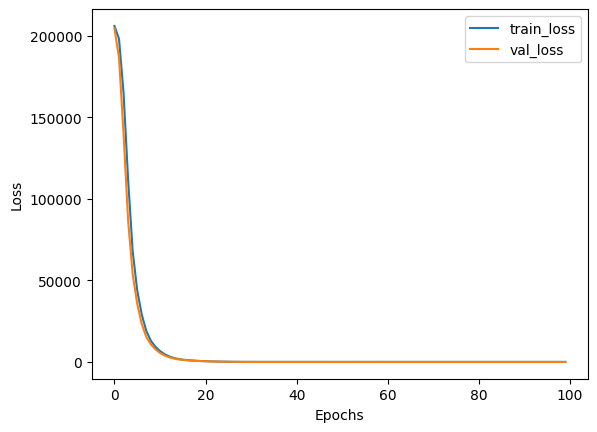

In [143]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({"train_loss" : train_losses , "val_loss" : val_losses})
plt.plot(loss_df , label=loss_df.columns.values)
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")

In [144]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [145]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse = criterion(train_preds, y_train_tensor)
    test_mse = criterion(test_preds, y_test_tensor)

print("Train MSE: ", train_mse.item())
print("Test MSE: ", test_mse.item())

Train MSE:  21.149517059326172
Test MSE:  19.56610679626465


In [147]:
from sklearn.metrics import r2_score
print("R2 Score: ", r2_score(y_train_tensor, train_preds)*100)

R2 Score:  92.76993870735168


In [152]:
# 2. Create the DataFrames
# test_preds is a PyTorch tensor, so .numpy() is correct here
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted"])

# FIX 1: y_test is a Pandas Series, so use .to_numpy()
# (Alternatively, you could use y_test_tensor.numpy() if you prefer)
actual_df = pd.DataFrame(y_test.to_numpy(), columns=["Actual"])

# FIX 2: Pass the DataFrames as a list inside pd.concat()
results_df = pd.concat([predicted_df, actual_df], axis=1)

# Display the first few rows to verify
print("\nPrediction Results:")
print(results_df.head())


Prediction Results:
    Predicted  Actual
0  435.698120  433.27
1  437.170654  438.16
2  461.036285  458.42
3  475.808777  480.82
4  435.538391  441.41
